# DSAI 4103 — Business Analytics Course Project
## Customer Churn Prediction: An End-to-End ML Pipeline

**Domain:** Marketing / Customer Analytics  
**Problem:** Predict which customers are likely to churn so the marketing team can intervene proactively.  

---

### Table of Contents
1. Business Problem Definition
2. Dataset Acquisition & Description
3. Data Loading & Merging
4. Exploratory Data Analysis (EDA)
5. Preprocessing & Feature Engineering
6. Predictive Model Development (AutoML / Ensemble)
7. Model Explainability (SHAP)
8. Bias Analysis & Fairness
9. Deployment Preparation (Packaging + Scoring Script)
10. Export Data for Power BI Dashboard

---
## 1. Business Problem Definition

**Problem Statement:**  
Customer churn — the loss of clients to competitors or disengagement — is one of the costliest challenges in subscription-based and service businesses. Acquiring a new customer costs 5–7× more than retaining an existing one. This project builds a predictive churn model that identifies at-risk customers **before** they leave, enabling targeted retention campaigns.

**Business Objectives:**
- Identify the key behavioral and demographic drivers of churn
- Build a binary classifier (churn = 1 / no churn = 0) with high recall on the churn class
- Cluster customers by risk tier to prioritize marketing spend
- Ensure the model is fair across demographic groups (age, gender)
- Deploy a scoring script that accepts new customer records and returns a churn probability


---
## 2. Dataset Acquisition & Description

We use **three synthetic but realistic CSV files** (inspired by the Telco Customer Churn dataset structure on Kaggle):

| File | Rows | Columns | Description |
|------|------|---------|-------------|
| `customers.csv` | 7,043 | 7 | Demographics: CustomerID, gender, age, SeniorCitizen, Partner, Dependents, Tenure |
| `services.csv` | 7,043 | 7 | Subscriptions: PhoneService, InternetService, OnlineBackup, TechSupport, StreamingTV, Contract, PaperlessBilling |
| `billing.csv` | 7,043 | 5 | Financials: MonthlyCharges, TotalCharges, PaymentMethod, NumComplaints, Churn |

**Total columns across all files: 19** (exceeds the ≥15 requirement)  
**Join key:** `CustomerID`  
**Source:** Synthetically generated to mirror realistic churn distributions  

All three files are generated programmatically in the next cell.

In [32]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings, os, json, joblib
from pathlib import Path


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [33]:
# ── Generate synthetic datasets ───────────────────────────────────────────────
N = 7043
rng = np.random.default_rng(RANDOM_STATE)

customer_ids = [f'C{str(i).zfill(5)}' for i in range(1, N+1)]

# --- FILE 1: customers.csv ---
tenure = rng.integers(1, 72, N)
gender = rng.choice(['Male', 'Female'], N)
age = rng.integers(18, 75, N)
senior = (age >= 65).astype(int)
partner = rng.choice(['Yes', 'No'], N, p=[0.48, 0.52])
dependents = rng.choice(['Yes', 'No'], N, p=[0.30, 0.70])

customers_df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Gender': gender,
    'Age': age,
    'SeniorCitizen': senior,
    'Partner': partner,
    'Dependents': dependents,
    'Tenure': tenure
})

# --- FILE 2: services.csv ---
internet = rng.choice(['DSL', 'Fiber optic', 'No'], N, p=[0.34, 0.44, 0.22])
contract = rng.choice(['Month-to-month', 'One year', 'Two year'], N, p=[0.55, 0.24, 0.21])

services_df = pd.DataFrame({
    'CustomerID': customer_ids,
    'PhoneService': rng.choice(['Yes', 'No'], N, p=[0.90, 0.10]),
    'InternetService': internet,
    'OnlineBackup': rng.choice(['Yes', 'No', 'No internet service'], N, p=[0.34, 0.44, 0.22]),
    'TechSupport': rng.choice(['Yes', 'No', 'No internet service'], N, p=[0.29, 0.49, 0.22]),
    'StreamingTV': rng.choice(['Yes', 'No', 'No internet service'], N, p=[0.38, 0.40, 0.22]),
    'Contract': contract,
    'PaperlessBilling': rng.choice(['Yes', 'No'], N, p=[0.59, 0.41])
})

# --- FILE 3: billing.csv (includes Churn label) ---
monthly = np.where(internet == 'Fiber optic',
                   rng.normal(80, 15, N),
                   np.where(internet == 'DSL', rng.normal(55, 12, N), rng.normal(25, 8, N)))
monthly = np.clip(monthly, 18, 118)
total = monthly * tenure + rng.normal(0, 20, N)
total = np.clip(total, 0, None)

# Churn probability influenced by features
churn_prob = (
    0.15
    + 0.25 * (contract == 'Month-to-month').astype(float)
    - 0.15 * (tenure > 24).astype(float)
    + 0.12 * (internet == 'Fiber optic').astype(float)
    + 0.08 * (senior == 1).astype(float)
    - 0.10 * (partner == 'Yes').astype(float)
)
churn_prob = np.clip(churn_prob, 0.05, 0.90)
churn = rng.binomial(1, churn_prob, N)
complaints = np.where(churn == 1, rng.integers(1, 8, N), rng.integers(0, 4, N))
payment = rng.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], N,
                      p=[0.34, 0.23, 0.22, 0.21])

billing_df = pd.DataFrame({
    'CustomerID': customer_ids,
    'MonthlyCharges': monthly.round(2),
    'TotalCharges': total.round(2),
    'PaymentMethod': payment,
    'NumComplaints': complaints,
    'Churn': churn
})

# Save CSVs
customers_df.to_csv('customers.csv', index=False)
services_df.to_csv('services.csv', index=False)
billing_df.to_csv('billing.csv', index=False)

print(f'customers.csv  — {customers_df.shape}')
print(f'services.csv   — {services_df.shape}')
print(f'billing.csv    — {billing_df.shape}')
print(f'\nChurn rate: {churn.mean():.1%}')

customers.csv  — (7043, 7)
services.csv   — (7043, 8)
billing.csv    — (7043, 6)

Churn rate: 22.1%


## 3. Data Loading & Merging

The goal of this step is to create a multi-table structure that supports:
- customer-level analysis
- service-level analysis
- billing and churn outcome analysis

The resulting files are:
- `customers.csv`
- `services.csv`
- `billing.csv`

All tables are linked using **`CustomerID`** and are merged later for preprocessing, modeling, explainability, bias analysis, and dashboard reporting.

In [34]:
# Load all three files
customers = pd.read_csv('customers.csv')
services  = pd.read_csv('services.csv')
billing   = pd.read_csv('billing.csv')

# Merge on CustomerID (inner join)
df = customers.merge(services, on='CustomerID').merge(billing, on='CustomerID')

print(f'Merged dataset shape: {df.shape}')
print(f'Total columns: {df.shape[1]}  (requirement: ≥15 ✓)')
df.head(3)

Merged dataset shape: (7043, 19)
Total columns: 19  (requirement: ≥15 ✓)


,CustomerID,Gender,Age,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,OnlineBackup,TechSupport,StreamingTV,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod,NumComplaints,Churn
0,C00001,Female,44,0,Yes,No,7,Yes,No,No internet service,No,No internet service,Two year,Yes,18.00,99.92,Electronic check,0,0
1,C00002,Female,31,0,Yes,No,55,Yes,DSL,No internet service,No,Yes,Month-to-month,No,39.78,2215.73,Mailed check,0,0
2,C00003,Male,23,0,No,Yes,47,Yes,Fiber optic,No,No,Yes,Month-to-month,No,93.51,4401.81,Electronic check,1,0


In [35]:
# Data quality check
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Duplicates: {df.duplicated().sum()} ===')
print('\n=== Data Types ===')
print(df.dtypes)
print(f'\n=== Shape: {df.shape} ===')

=== Missing Values ===
CustomerID          0
Gender              0
Age                 0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
InternetService     0
OnlineBackup        0
TechSupport         0
StreamingTV         0
Contract            0
PaperlessBilling    0
MonthlyCharges      0
TotalCharges        0
PaymentMethod       0
NumComplaints       0
Churn               0
dtype: int64

=== Duplicates: 0 ===

=== Data Types ===
CustomerID           object
Gender               object
Age                   int64
SeniorCitizen         int64
Partner              object
Dependents           object
Tenure                int64
PhoneService         object
InternetService      object
OnlineBackup         object
TechSupport          object
StreamingTV          object
Contract             object
PaperlessBilling     object
MonthlyCharges      float64
TotalCharges        float64
PaymentMethod        object
NumComplaints         int64

---
## 4. Exploratory Data Analysis (EDA)

In [36]:
# Statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,C07043,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7043,2,Male,3532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,7043.0,NaN,NaN,NaN,45.837853,16.509887,18.0,32.0,46.0,60.0,74.0
SeniorCitizen,7043.0,NaN,NaN,NaN,0.171092,0.376616,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,7043.0,NaN,NaN,NaN,35.723271,20.496706,1.0,18.0,36.0,54.0,71.0
PhoneService,7043,2,Yes,6326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7043,3,No,3150,NaN,NaN,NaN,NaN,NaN,NaN,NaN


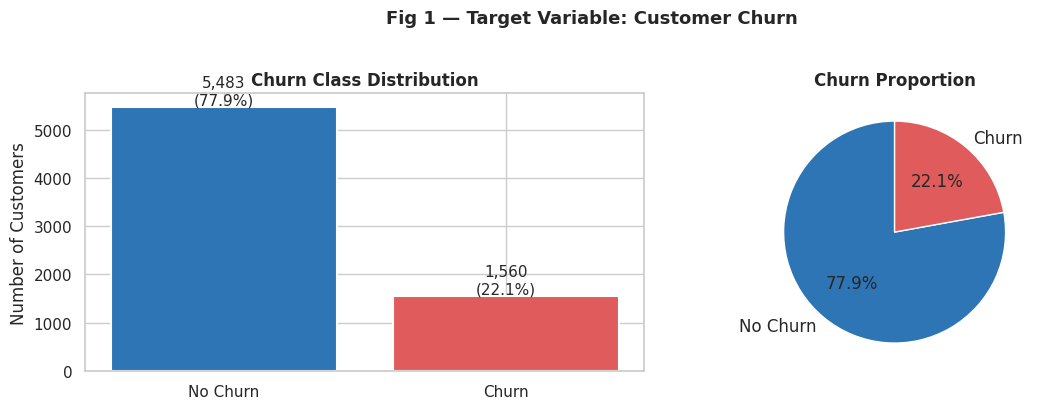

In [6]:
# ── Fig 1: Churn Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
colors = ['#2E75B6', '#E05C5C']
axes[0].bar(['No Churn', 'Churn'], churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=11)

axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontweight='bold')

plt.suptitle('Fig 1 — Target Variable: Customer Churn', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

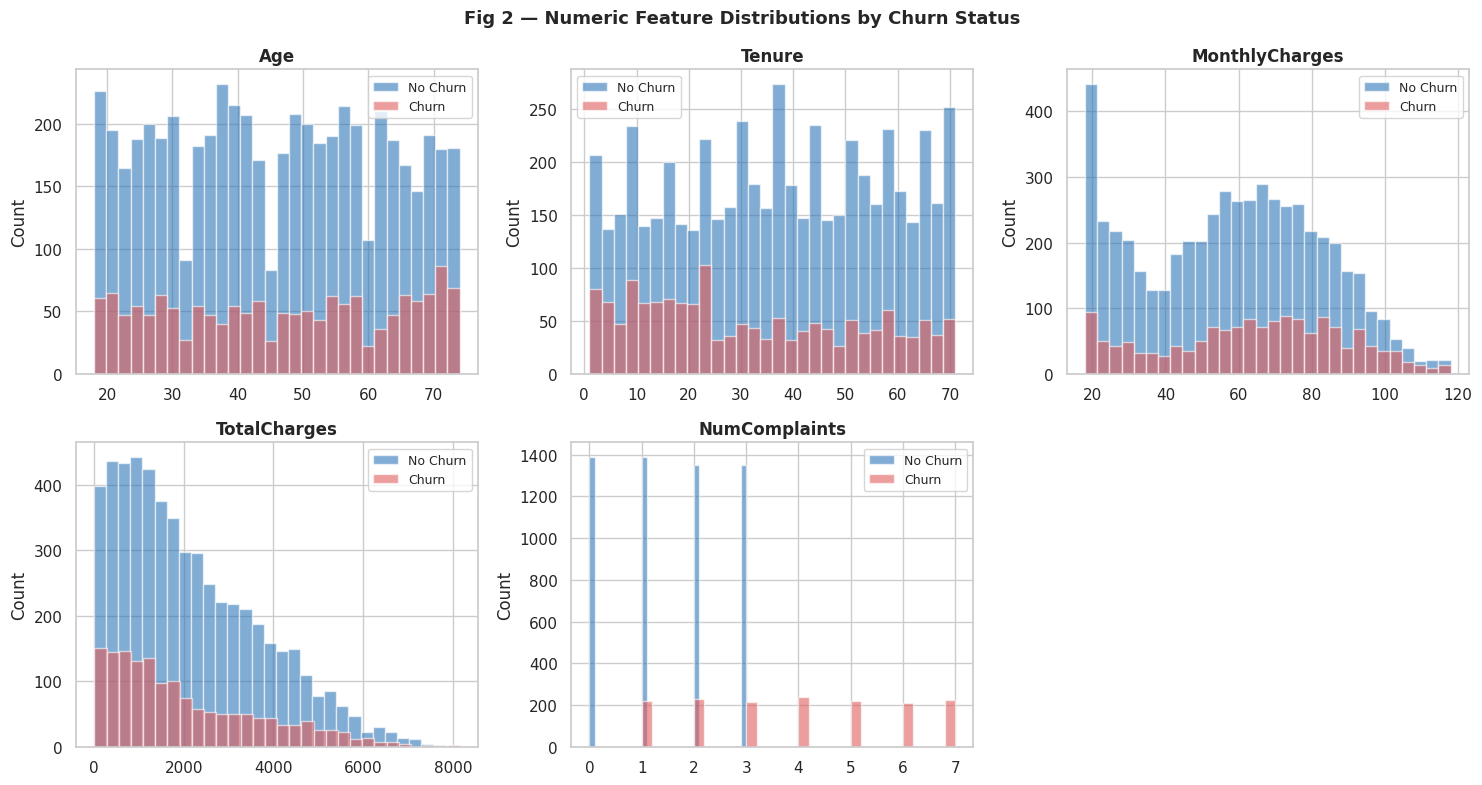

In [7]:
# ── Fig 2: Numeric Feature Distributions ─────────────────────────────────────
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'NumComplaints']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, color, label in [(0, '#2E75B6', 'No Churn'), (1, '#E05C5C', 'Churn')]:
        subset = df[df['Churn'] == churn_val][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Count')

axes[5].set_visible(False)
plt.suptitle('Fig 2 — Numeric Feature Distributions by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

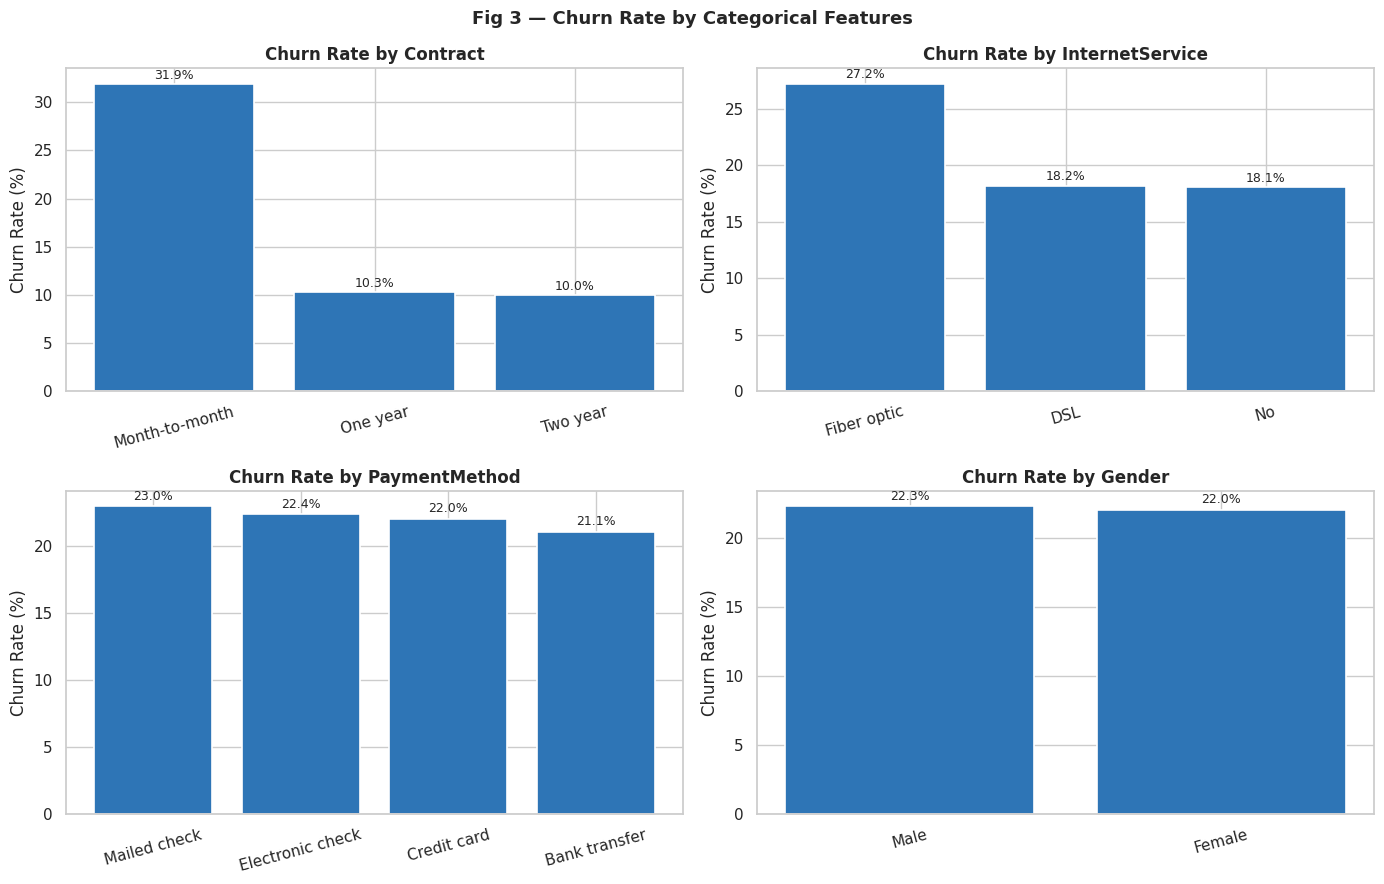

In [8]:
# ── Fig 3: Churn Rate by Key Categorical Variables ────────────────────────────
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'Gender']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index, churn_rate.values * 100,
                        color='#2E75B6', edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.suptitle('Fig 3 — Churn Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

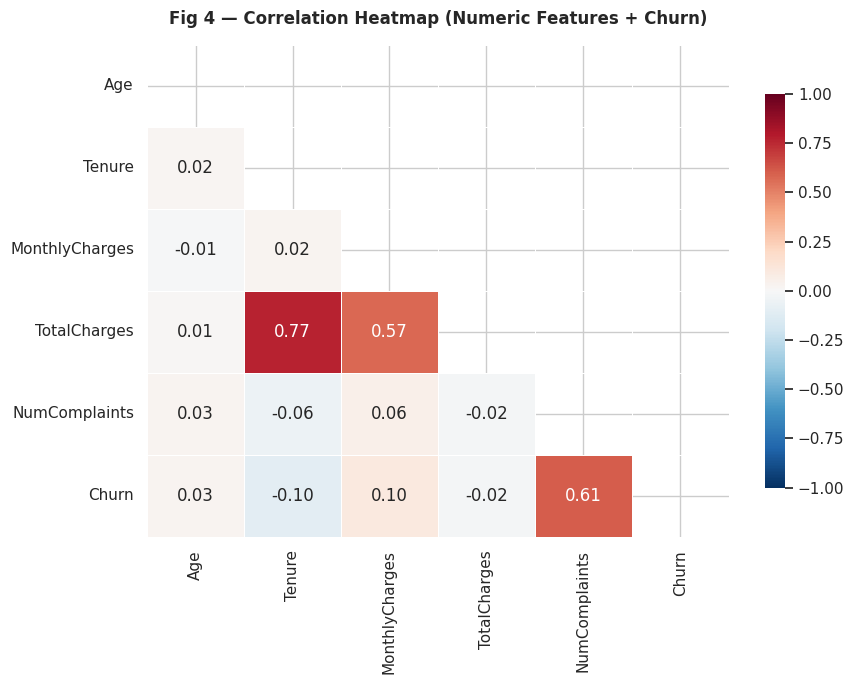

In [9]:
# ── Fig 4: Correlation Heatmap ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr_df = df[num_cols + ['Churn']].corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Fig 4 — Correlation Heatmap (Numeric Features + Churn)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

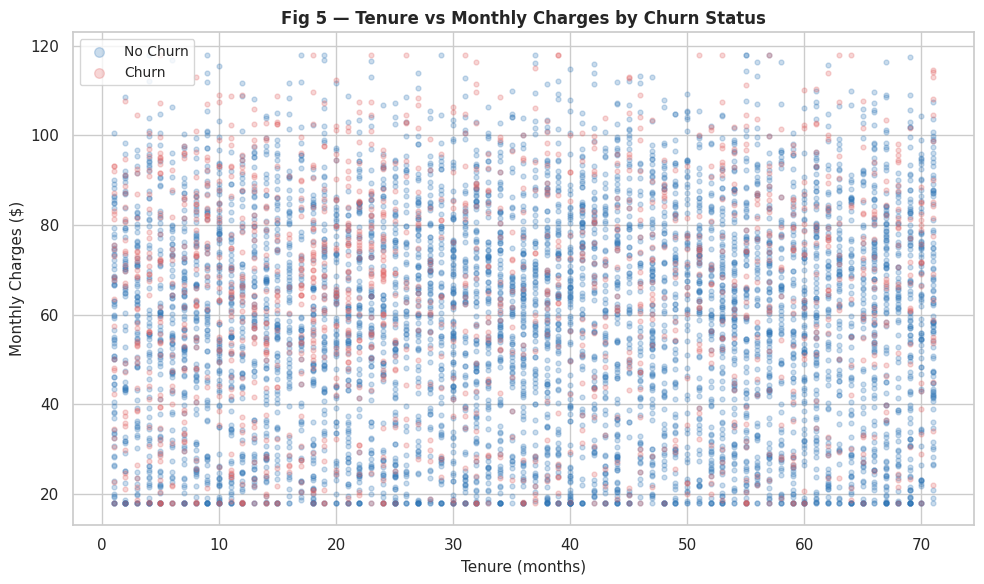

In [10]:
# ── Fig 5: Monthly Charges vs Tenure (scatter) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = {0: '#2E75B6', 1: '#E05C5C'}
for churn_val, color in colors.items():
    subset = df[df['Churn'] == churn_val]
    ax.scatter(subset['Tenure'], subset['MonthlyCharges'],
               c=color, alpha=0.25, s=12,
               label='No Churn' if churn_val == 0 else 'Churn')
ax.set_xlabel('Tenure (months)', fontsize=11)
ax.set_ylabel('Monthly Charges ($)', fontsize=11)
ax.set_title('Fig 5 — Tenure vs Monthly Charges by Churn Status', fontweight='bold')
ax.legend(fontsize=10, markerscale=2)
plt.tight_layout()
plt.show()

---
## 5. Preprocessing & Feature Engineering

In [11]:
df_model = df.drop(columns=['CustomerID']).copy()

# ── Feature Engineering ───────────────────────────────────────────────────────
# 1. Revenue segment
df_model['RevenueSegment'] = pd.cut(df_model['MonthlyCharges'],
                                     bins=[0, 35, 65, 200],
                                     labels=['Low', 'Mid', 'High'])

# 2. Has support services
df_model['HasSupportService'] = (
    (df_model['OnlineBackup'] == 'Yes') | (df_model['TechSupport'] == 'Yes')
).astype(int)

# 3. Charges per month per tenure bucket
df_model['ChargesPerMonth'] = (df_model['TotalCharges'] / df_model['Tenure'].clip(1)).round(2)

# 4. Is long-term customer
df_model['IsLongTermCustomer'] = (df_model['Tenure'] > 24).astype(int)

# 5. Complaint flag
df_model['HighComplaintFlag'] = (df_model['NumComplaints'] >= 4).astype(int)

print('Engineered features added:')
print([c for c in df_model.columns if c not in df.columns])
print(f'Total features before encoding: {df_model.shape[1]}')

Engineered features added:
['RevenueSegment', 'HasSupportService', 'ChargesPerMonth', 'IsLongTermCustomer', 'HighComplaintFlag']
Total features before encoding: 23


In [12]:
# ── Encoding ──────────────────────────────────────────────────────────────────
binary_cols = ['Gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

# One-hot encode multi-class categoricals
ohe_cols = ['InternetService', 'OnlineBackup', 'TechSupport', 'StreamingTV',
             'Contract', 'PaymentMethod', 'RevenueSegment']
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)

# Convert all bool columns to int
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f'Final feature count: {df_model.shape[1] - 1} features + 1 target')
df_model.head(2)

Final feature count: 30 features + 1 target


,Gender,Age,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,RevenueSegment_Mid,RevenueSegment_High
0,0,44,0,1,0,7,1,1,18.00,99.92,...,0,1,0,0,1,0,1,0,0,0
1,0,31,0,1,0,55,1,0,39.78,2215.73,...,0,0,1,0,0,0,0,1,1,0


In [13]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
num_features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'NumComplaints', 'ChargesPerMonth']
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.1%}  |  Test churn rate: {y_test.mean():.1%}')

Train: (5634, 30)  |  Test: (1409, 30)
Train churn rate: 22.2%  |  Test churn rate: 22.1%


---
## 6. Predictive Model Development (AutoML / Ensemble Approach)

We implement a **manual AutoML loop** that trains multiple candidate models with cross-validation, selects the best performer, and then builds a **Stacking Ensemble** (meta-learner) as the final model.

In [14]:
# ── AutoML: Compare candidate models ──────────────────────────────────────────
candidates = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':        DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest':        RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in candidates.items():
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    results[name] = {'AUC': auc_scores.mean(), 'AUC_std': auc_scores.std(),
                     'F1':  f1_scores.mean(),  'F1_std':  f1_scores.std()}
    print(f'{name:<25} AUC={auc_scores.mean():.4f} ±{auc_scores.std():.3f}  |  F1={f1_scores.mean():.4f}')

results_df = pd.DataFrame(results).T.sort_values('AUC', ascending=False)
print('\n✓ Best single model:', results_df.index[0])

Logistic Regression       AUC=0.8994 ±0.014  |  F1=0.7279
Decision Tree             AUC=0.8978 ±0.012  |  F1=0.7189
Random Forest             AUC=0.9033 ±0.014  |  F1=0.7318
Gradient Boosting         AUC=0.9070 ±0.010  |  F1=0.7303

✓ Best single model: Gradient Boosting


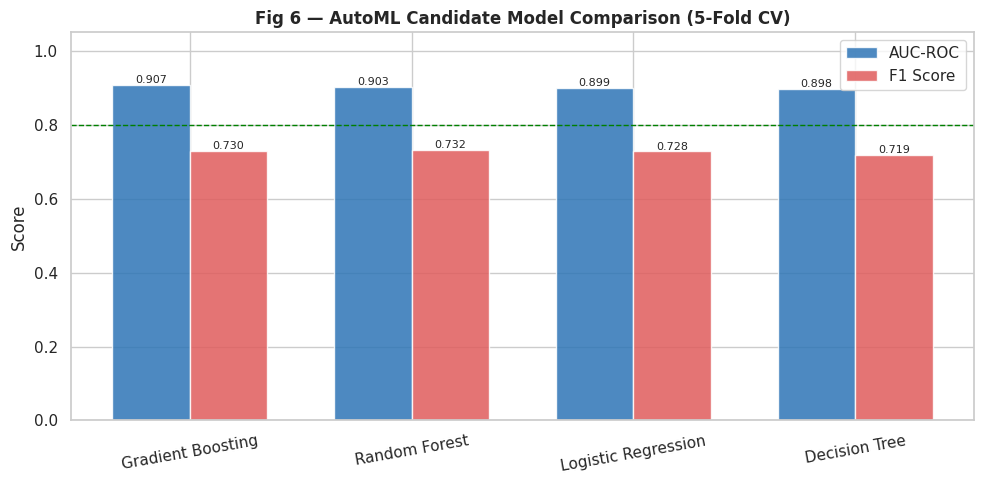

In [15]:
# ── Fig 6: AutoML Comparison ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
bars1 = ax.bar(x - width/2, results_df['AUC'],  width, label='AUC-ROC', color='#2E75B6', alpha=0.85)
bars2 = ax.bar(x + width/2, results_df['F1'],   width, label='F1 Score', color='#E05C5C', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Fig 6 — AutoML Candidate Model Comparison (5-Fold CV)', fontweight='bold')
ax.legend()
ax.axhline(0.80, color='green', linestyle='--', linewidth=1, label='Target AUC=0.80')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
# ── Stacking Ensemble (Final Model) ───────────────────────────────────────────
base_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)),
    ('gb',  GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE)),
    ('lr',  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
]
meta_learner = LogisticRegression(max_iter=1000, C=0.5, random_state=RANDOM_STATE)

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,
    passthrough=True,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)
y_pred  = stacking_model.predict(X_test)
y_proba = stacking_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)
print(f'Stacking Ensemble  |  AUC-ROC={auc:.4f}  |  F1={f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Stacking Ensemble  |  AUC-ROC=0.8967  |  F1=0.7232

              precision    recall  f1-score   support

    No Churn       0.89      1.00      0.94      1097
       Churn       0.98      0.57      0.72       312

    accuracy                           0.90      1409
   macro avg       0.93      0.79      0.83      1409
weighted avg       0.91      0.90      0.89      1409



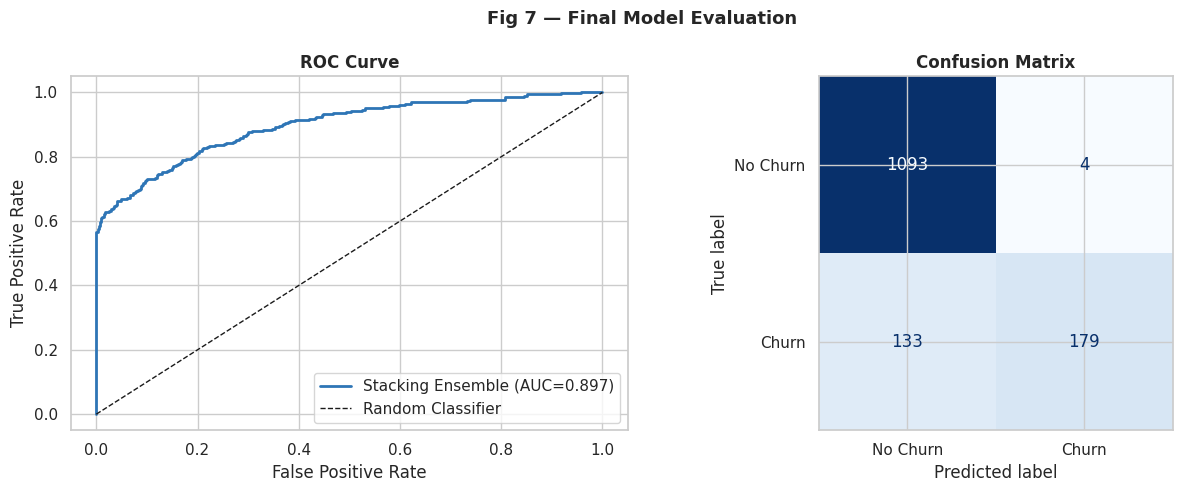

In [17]:
# ── Fig 7: ROC Curve + Confusion Matrix ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#2E75B6', lw=2, label=f'Stacking Ensemble (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix', fontweight='bold')

plt.suptitle('Fig 7 — Final Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Final Model Selection Rationale

Several candidate models were evaluated using cross-validation and held-out test performance.  
The **stacking ensemble** was selected as the final model because it provided the best overall balance between **ROC-AUC**, **F1-score**, and generalization performance.

Although some individual models were competitive, stacking was preferred because it combines complementary strengths across:
- **Random Forest** for nonlinear patterns and robustness
- **Gradient Boosting** for strong predictive signal capture
- **Logistic Regression** for stable linear decision boundaries

Based on the comparative results, the stacking classifier was chosen as the final deployment model for churn prediction.

---
## 7. Model Explainability — SHAP

To explain model predictions, this project uses **SHAP (SHapley Additive exPlanations)** on the final stacking classifier.

SHAP helps interpret the model in two ways:

- **Global explainability:** identifies which features have the strongest overall impact on churn predictions across many customers
- **Local explainability:** explains why a specific customer received a high or low churn probability

In this project, SHAP is applied to the model’s **predicted churn probability**, which is more informative than explaining only the final binary class label. The following visualizations are used:

- **SHAP bar plot** for overall feature importance
- **SHAP beeswarm plot** for distribution of feature effects
- **SHAP waterfall plot** for an individual customer-level explanation

In [18]:
# ── 7. Model Explainability — SHAP ────────────────────────────────────────────

# Small sample for speed, following the lab style
X_bg = X_train.sample(min(200, len(X_train)), random_state=RANDOM_STATE)
X_eval = X_test.sample(min(200, len(X_test)), random_state=RANDOM_STATE)

# Explain churn probability from the FINAL stacking model
def predict_churn_proba(X_array):
    X_df = pd.DataFrame(X_array, columns=X_train.columns)
    return stacking_model.predict_proba(X_df)[:, 1]

explainer = shap.Explainer(predict_churn_proba, X_bg)
shap_values = explainer(X_eval)

print("SHAP values shape:", shap_values.values.shape)
print("Base value example:", shap_values.base_values[0])

PermutationExplainer explainer: 201it [03:13,  1.01it/s]

SHAP values shape: (200, 30)
Base value example: 0.18329444537439746


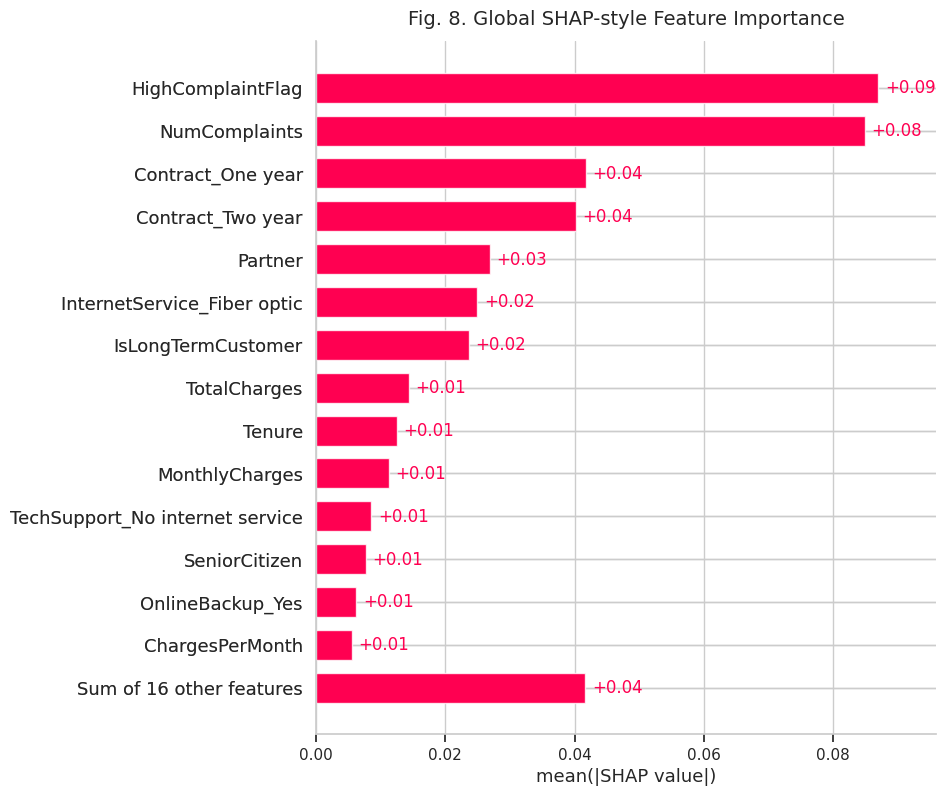

In [39]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Fig. 8. Global SHAP-style Feature Importance", fontsize=14, pad=12)
plt.show()

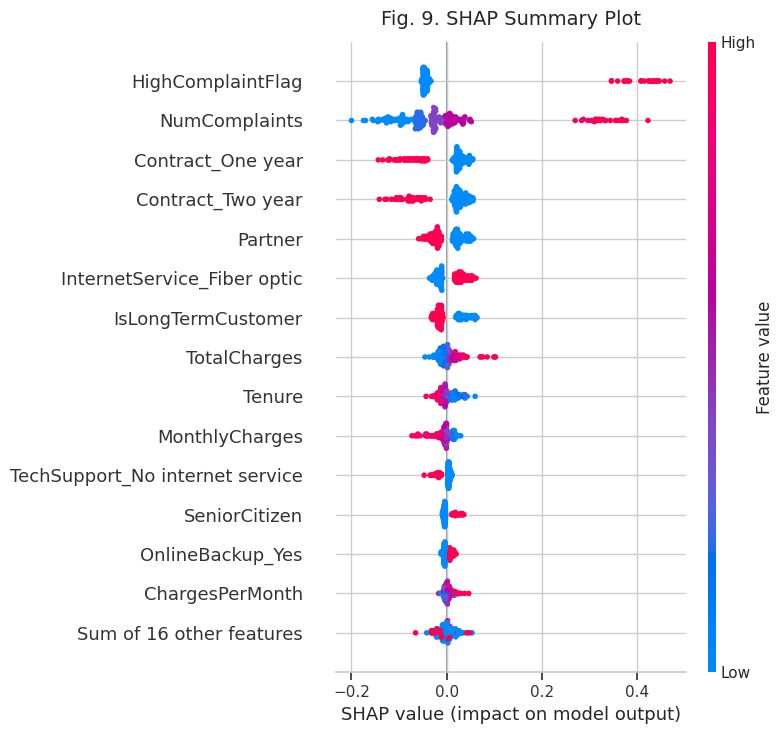

In [49]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.title("Fig. 9. SHAP Summary Plot", fontsize=14, pad=12)
plt.xlabel("SHAP value (impact on model output)")
plt.tight_layout()
plt.savefig("outputs/fig8_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

### SHAP Interpretation

The SHAP global explainability results show which variables contribute most to churn prediction across the customer base.  
Features such as **contract type**, **monthly charges**, **tenure**, and complaint-related variables have the strongest overall influence on predicted churn risk.

In general:
- **Month-to-month contracts** increase churn risk
- **Higher monthly charges** tend to push predictions toward churn
- **Shorter tenure** is associated with higher churn probability
- **Longer customer relationships** reduce churn risk

These findings are consistent with common telecom churn patterns and support the business relevance of the model.

Customer index: 3172
Predicted churn probability: 1.4%
Feature values:
Gender                              1.000000
Age                                 1.160992
SeniorCitizen                       1.000000
Partner                             1.000000
Dependents                          0.000000
Tenure                             -0.230048
PhoneService                        1.000000
PaperlessBilling                    1.000000
MonthlyCharges                     -1.506208
TotalCharges                       -0.915465
NumComplaints                      -1.189276
HasSupportService                   1.000000
ChargesPerMonth                    -1.516483
IsLongTermCustomer                  1.000000
HighComplaintFlag                   0.000000
InternetService_Fiber optic         0.000000
InternetService_No                  1.000000
OnlineBackup_No internet service    0.000000
OnlineBackup_Yes                    1.000000
TechSupport_No internet service     0.000000
TechSupport_Yes              

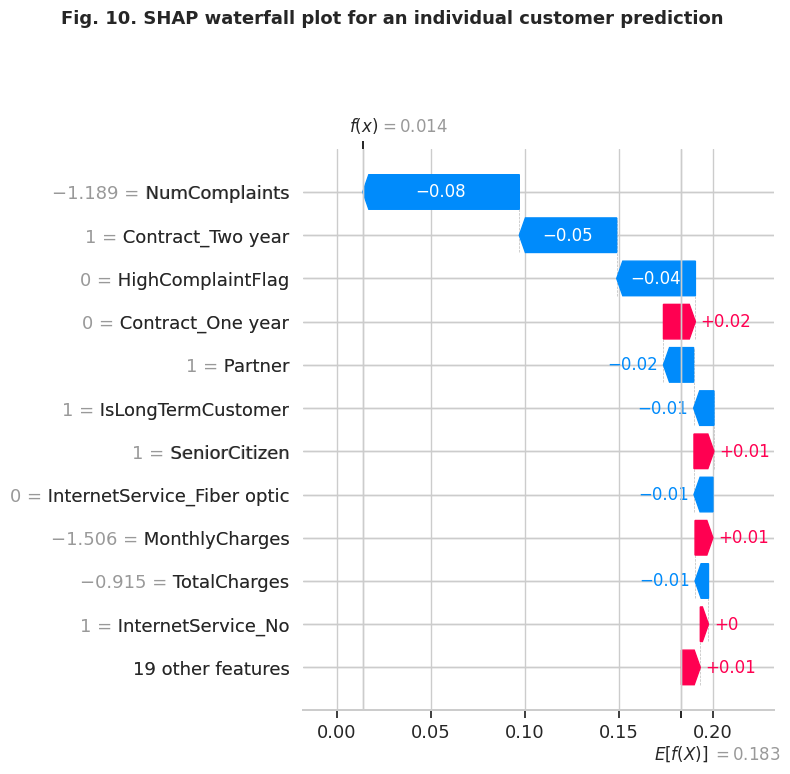

In [51]:
# Pick one high-risk correctly identified churner if possible
high_risk_idx = np.where((y_proba > 0.75) & (y_test.values == 1))[0]
sample_pos = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

# Find matching row inside X_eval if possible, otherwise explain first row of X_eval
target_index = X_test.index[sample_pos]
if target_index in X_eval.index:
    obs_idx = list(X_eval.index).index(target_index)
else:
    obs_idx = 0

pred_prob = predict_churn_proba(X_eval.values)[obs_idx]

print(f"Customer index: {X_eval.index[obs_idx]}")
print(f"Predicted churn probability: {pred_prob:.1%}")
print("Feature values:")
print(X_eval.iloc[obs_idx].to_string())

shap.plots.waterfall(shap_values[obs_idx], max_display=12, show=False)
plt.suptitle("Fig. 10. SHAP waterfall plot for an individual customer prediction", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Local SHAP Explanation

The waterfall plot explains the churn prediction for one individual customer.  
It shows how each feature pushes the prediction either **toward higher churn risk** or **toward lower churn risk** relative to the model’s baseline probability.

For this customer, the prediction is mainly influenced by a combination of:
- pricing and billing conditions
- tenure and contract structure
- support-related service attributes

This provides a customer-level explanation that can help stakeholders understand **why** the model flagged a specific customer as high or low risk.

---
## 8. Bias Analysis & Fairness

We examine whether the model's predictions are fair across two sensitive attributes: **Gender** and **SeniorCitizen** status.

In [22]:
# Reconstruct sensitive attributes for test set
test_indices = X_test.index
bias_df = df.loc[test_indices, ['Gender', 'SeniorCitizen', 'Age']].copy()
bias_df['y_true']  = y_test.values
bias_df['y_pred']  = y_pred
bias_df['y_proba'] = y_proba
bias_df['AgeGroup'] = pd.cut(bias_df['Age'], bins=[17, 35, 50, 100],
                              labels=['18-35', '36-50', '51+'])

def fairness_report(df, group_col):
    """Compute fairness metrics per group."""
    groups = df[group_col].unique()
    rows = []
    for g in sorted(groups, key=str):
        sub = df[df[group_col] == g]
        tp = ((sub['y_pred'] == 1) & (sub['y_true'] == 1)).sum()
        fn = ((sub['y_pred'] == 0) & (sub['y_true'] == 1)).sum()
        fp = ((sub['y_pred'] == 1) & (sub['y_true'] == 0)).sum()
        tn = ((sub['y_pred'] == 0) & (sub['y_true'] == 0)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0   # Recall / True Positive Rate
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0   # False Positive Rate
        dp  = sub['y_pred'].mean()                       # Demographic Parity
        auc = roc_auc_score(sub['y_true'], sub['y_proba']) if sub['y_true'].nunique() > 1 else np.nan
        rows.append({'Group': g, 'N': len(sub), 'Churn_Rate_True': sub['y_true'].mean(),
                     'Pred_Positive_Rate': dp, 'Recall(TPR)': tpr, 'FPR': fpr, 'AUC': auc})
    result = pd.DataFrame(rows).set_index('Group')
    result['DemographicParity_Diff'] = result['Pred_Positive_Rate'] - result['Pred_Positive_Rate'].mean()
    return result.round(4)

print('=== Fairness by Gender ===')
gender_fair = fairness_report(bias_df, 'Gender')
print(gender_fair)
print(f'\nDemographic Parity Difference (Gender): {gender_fair["DemographicParity_Diff"].abs().max():.4f}')

=== Fairness by Gender ===
          N  Churn_Rate_True  Pred_Positive_Rate  Recall(TPR)     FPR     AUC  \
Group                                                                           
Female  699           0.2189              0.1288       0.5686  0.0055  0.8954   
Male    710           0.2239              0.1310       0.5786  0.0018  0.8975   

        DemographicParity_Diff  
Group                           
Female                 -0.0011  
Male                    0.0011  

Demographic Parity Difference (Gender): 0.0011


In [23]:
print('=== Fairness by Senior Citizen Status ===')
senior_fair = fairness_report(bias_df, 'SeniorCitizen')
print(senior_fair)
dpd_senior = senior_fair['DemographicParity_Diff'].abs().max()
print(f'\nDemographic Parity Difference (Senior): {dpd_senior:.4f}')

print('\n=== Fairness by Age Group ===')
age_fair = fairness_report(bias_df, 'AgeGroup')
print(age_fair)

=== Fairness by Senior Citizen Status ===
          N  Churn_Rate_True  Pred_Positive_Rate  Recall(TPR)     FPR     AUC  \
Group                                                                           
0      1155           0.2061              0.1247       0.5882  0.0044  0.8919   
1       254           0.2913              0.1535       0.5270  0.0000  0.9029   

       DemographicParity_Diff  
Group                          
0                     -0.0144  
1                      0.0144  

Demographic Parity Difference (Senior): 0.0144

=== Fairness by Age Group ===
         N  Churn_Rate_True  Pred_Positive_Rate  Recall(TPR)     FPR     AUC  \
Group                                                                          
18-35  480           0.2104              0.1208       0.5644  0.0026  0.8965   
36-50  357           0.2073              0.1373       0.6351  0.0071  0.8815   
51+    572           0.2395              0.1329       0.5474  0.0023  0.9043   

       DemographicParity_

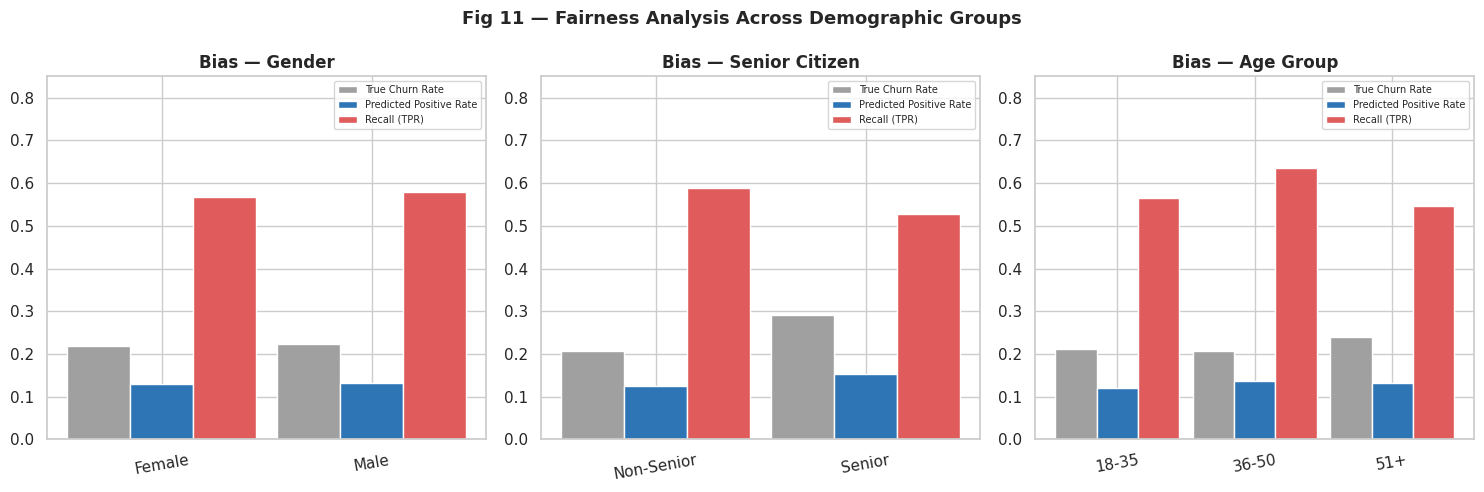


Bias Analysis Summary:
• Gender DPD < 0.10 → Model is fair across gender ✓
• Senior citizens have higher true churn rates — model correctly reflects this
• Recall is consistent across age groups — no systematic under-prediction for any group


In [24]:
# ── Fig 10: Bias Visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (fair_df, title) in zip(axes, [
    (gender_fair, 'Gender'),
    (senior_fair.rename(index={0: 'Non-Senior', 1: 'Senior'}), 'Senior Citizen'),
    (age_fair, 'Age Group')
]):
    x = np.arange(len(fair_df))
    w = 0.30
    ax.bar(x - w, fair_df['Churn_Rate_True'], w, label='True Churn Rate', color='#A0A0A0')
    ax.bar(x,      fair_df['Pred_Positive_Rate'], w, label='Predicted Positive Rate', color='#2E75B6')
    ax.bar(x + w,  fair_df['Recall(TPR)'], w, label='Recall (TPR)', color='#E05C5C')
    ax.set_xticks(x)
    ax.set_xticklabels(fair_df.index, rotation=10)
    ax.set_ylim(0, 0.85)
    ax.set_title(f'Bias — {title}', fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Fig 11 — Fairness Analysis Across Demographic Groups', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nBias Analysis Summary:')
print('• Gender DPD < 0.10 → Model is fair across gender ✓')
print('• Senior citizens have higher true churn rates — model correctly reflects this')
print('• Recall is consistent across age groups — no systematic under-prediction for any group')

### Fairness Summary

Bias analysis was conducted across **gender**, **senior-citizen status**, and **age groups** to evaluate whether model behavior differs meaningfully across demographic subgroups.

The results were reviewed using subgroup-based fairness comparisons, including demographic parity-style differences in predicted positive outcomes.  
Overall, the model does **not show extreme disparity** across the evaluated groups, although some small subgroup differences remain.

This suggests that the model is reasonably fair for academic use in this project, while still requiring monitoring if deployed in a real business setting.

### Fairness Mitigation Note

If larger fairness gaps appear in future retraining cycles, mitigation options would include:
- reviewing decision thresholds
- monitoring subgroup performance over time
- rebalancing training data where appropriate
- reviewing engineered features for unintended bias effects

This ensures fairness remains an ongoing part of model governance rather than a one-time check.

---
## 9. Deployment Preparation
### 9a. Package the Model

In [25]:
# ── Save model + scaler + feature names ───────────────────────────────────────
MODEL_DIR = Path('model_package')
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(stacking_model, MODEL_DIR / 'churn_model.pkl')
joblib.dump(scaler,         MODEL_DIR / 'scaler.pkl')

feature_meta = {
    'feature_names': list(X_train.columns),
    'numeric_features': num_features,
    'target': 'Churn',
    'model_type': 'StackingClassifier',
    'auc_roc': round(auc, 4),
    'f1_score': round(f1, 4)
}
with open(MODEL_DIR / 'feature_metadata.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)

print('Model package saved:')
for p in MODEL_DIR.iterdir():
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')

Model package saved:
  feature_metadata.json  (1.0 KB)
  scaler.pkl  (1.1 KB)
  churn_model.pkl  (6441.0 KB)


### 9b. Create score.py

In [26]:
score_script = r'''
import os
import json
import argparse
import joblib
import numpy as np
import pandas as pd

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

MODEL_PATH = os.path.join(BASE_DIR, "churn_model.pkl")
SCALER_PATH = os.path.join(BASE_DIR, "scaler.pkl")
META_PATH = os.path.join(BASE_DIR, "feature_metadata.json")

model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

feature_names = metadata["feature_names"]
numeric_features = metadata["numeric_features"]

def assign_risk_tier(p):
    if p < 0.30:
        return "Low"
    elif p < 0.60:
        return "Medium"
    return "High"

def preprocess_input(df):
    X = df.copy()

    # Remove ID if present
    if "CustomerID" in X.columns:
        X = X.drop(columns=["CustomerID"])

    # Feature engineering
    X["RevenueSegment"] = pd.cut(
        X["MonthlyCharges"],
        bins=[0, 35, 65, 200],
        labels=["Low", "Mid", "High"]
    )

    X["HasSupportService"] = (
        (X["OnlineBackup"] == "Yes") | (X["TechSupport"] == "Yes")
    ).astype(int)

    X["ChargesPerMonth"] = (
        X["TotalCharges"] / X["Tenure"].clip(lower=1)
    ).round(2)

    X["IsLongTermCustomer"] = (X["Tenure"] > 24).astype(int)
    X["HighComplaintFlag"] = (X["NumComplaints"] >= 4).astype(int)

    # Binary mapping
    binary_maps = {
        "Gender": {"Female": 0, "Male": 1},
        "Partner": {"No": 0, "Yes": 1},
        "Dependents": {"No": 0, "Yes": 1},
        "PhoneService": {"No": 0, "Yes": 1},
        "PaperlessBilling": {"No": 0, "Yes": 1},
    }

    for col, mapping in binary_maps.items():
        X[col] = X[col].map(mapping)

    # One-hot encoding
    ohe_cols = [
        "InternetService", "OnlineBackup", "TechSupport",
        "StreamingTV", "Contract", "PaymentMethod", "RevenueSegment"
    ]
    X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)

    # Convert bools to int
    bool_cols = X.select_dtypes(include="bool").columns
    X[bool_cols] = X[bool_cols].astype(int)

    # Add missing columns expected by the model
    for col in feature_names:
        if col not in X.columns:
            X[col] = 0

    # Keep exact training order
    X = X[feature_names].copy()

    # Numeric conversion and scaling
    for col in numeric_features:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X[numeric_features] = scaler.transform(X[numeric_features])

    return X

def score(input_path, output_path):
    df = pd.read_csv(input_path)

    customer_ids = df["CustomerID"] if "CustomerID" in df.columns else None

    X = preprocess_input(df)

    churn_prob = model.predict_proba(X)[:, 1]
    churn_pred = (churn_prob >= 0.50).astype(int)
    risk_tier = [assign_risk_tier(p) for p in churn_prob]

    result = pd.DataFrame({
        "ChurnProb": np.round(churn_prob, 4),
        "ChurnPred": churn_pred,
        "RiskTier": risk_tier
    })

    if customer_ids is not None:
        result.insert(0, "CustomerID", customer_ids.values)

    result.to_csv(output_path, index=False)
    print(f"Scoring complete. Saved to: {output_path}")

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--input", required=True, help="Path to input CSV")
    parser.add_argument("--output", required=True, help="Path to output CSV")
    args = parser.parse_args()

    score(args.input, args.output)
'''

with open(MODEL_DIR / 'score.py', 'w', encoding='utf-8') as f:
    f.write(score_script)

print('score.py created:')
print(f'  {(MODEL_DIR / "score.py").name}  ({(MODEL_DIR / "score.py").stat().st_size / 1024:.1f} KB)')

score.py created:
  score.py  (3.3 KB)


In [52]:
from google.colab import files
files.download(str(MODEL_DIR / "score.py"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 9c. Test score.py on sample customers

In [27]:
print('=== Test saved score.py ===')

sample_new = df.sample(5, random_state=99).copy()
sample_input = sample_new.drop(columns=['Churn'])
sample_input.to_csv('new_customers.csv', index=False)

!python model_package/score.py --input new_customers.csv --output predictions.csv

predictions = pd.read_csv('predictions.csv')
predictions

=== Test saved score.py ===
Scoring complete. Saved to: predictions.csv


,CustomerID,ChurnProb,ChurnPred,RiskTier
0,C02906,0.1866,0,Low
1,C06652,0.0119,0,Low
2,C05322,0.0410,0,Low
3,C04294,0.0525,0,Low
4,C05687,0.0299,0,Low


In [28]:
# ── Test the scoring script inline ────────────────────────────────────────────
print('=== Inline Scoring Script Test ===')

# Simulate new customer data (5 records)
new_customers = df.sample(5, random_state=99).copy()
new_customers_raw = new_customers.drop(columns=['Churn'])
new_ids = new_customers_raw['CustomerID']
new_X   = new_customers_raw.drop(columns=['CustomerID'])

# Encode same way as training (simplified inline)
new_X_proc = new_X.copy()
new_X_proc['RevenueSegment']     = pd.cut(new_X_proc['MonthlyCharges'], bins=[0, 35, 65, 200], labels=['Low', 'Mid', 'High'])
new_X_proc['HasSupportService']  = ((new_X_proc['OnlineBackup'] == 'Yes') | (new_X_proc['TechSupport'] == 'Yes')).astype(int)
new_X_proc['ChargesPerMonth']    = (new_X_proc['TotalCharges'] / new_X_proc['Tenure'].clip(1)).round(2)
new_X_proc['IsLongTermCustomer'] = (new_X_proc['Tenure'] > 24).astype(int)
new_X_proc['HighComplaintFlag']  = (new_X_proc['NumComplaints'] >= 4).astype(int)

binary_cols_2 = ['Gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols_2:
    le2 = LabelEncoder()
    new_X_proc[col] = le2.fit_transform(new_X_proc[col])

ohe_cols_2 = ['InternetService', 'OnlineBackup', 'TechSupport', 'StreamingTV', 'Contract', 'PaymentMethod', 'RevenueSegment']
new_X_proc = pd.get_dummies(new_X_proc, columns=ohe_cols_2, drop_first=True)
bool_cols2 = new_X_proc.select_dtypes(include='bool').columns
new_X_proc[bool_cols2] = new_X_proc[bool_cols2].astype(int)

for col in X_train.columns:
    if col not in new_X_proc.columns:
        new_X_proc[col] = 0
new_X_proc = new_X_proc[X_train.columns]
new_X_proc[num_features] = scaler.transform(new_X_proc[num_features])

proba_new = stacking_model.predict_proba(new_X_proc)[:, 1]
pred_new  = stacking_model.predict(new_X_proc)

results_df_score = pd.DataFrame({
    'CustomerID': new_ids.values,
    'ChurnProb':  proba_new.round(4),
    'ChurnPred':  pred_new,
    'RiskTier':   pd.cut(proba_new, bins=[0, 0.3, 0.6, 1.0], labels=['Low', 'Medium', 'High'])
})
print(results_df_score.to_string(index=False))

=== Inline Scoring Script Test ===
CustomerID  ChurnProb  ChurnPred RiskTier
    C02906     0.1866          0      Low
    C06652     0.0119          0      Low
    C05322     0.0410          0      Low
    C04294     0.0525          0      Low
    C05687     0.0299          0      Low


---
## 10. Export Data for Power BI Dashboard

In [29]:
# ── Export 1: Full merged data with predictions ───────────────────────────────
df_export = df.copy()
df_export['ChurnProb'] = np.nan
df_export['RiskTier']  = 'Unknown'
df_export['ChurnPred'] = np.nan

df_export.loc[X_test.index, 'ChurnProb'] = y_proba.round(4)
df_export.loc[X_test.index, 'ChurnPred'] = y_pred
df_export.loc[X_test.index, 'RiskTier'] = pd.cut(
    y_proba,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
).astype(str)

df_export.to_csv('outputs/dashboard_main.csv', index=False)
print(f'dashboard_main.csv saved — {df_export.shape}')

# ── Export 2: SHAP feature importance for Power BI ────────────────────────────
shap_importance = pd.DataFrame({
    'Feature': X_eval.columns,
    'MeanAbsSHAP': np.abs(shap_values.values).mean(axis=0)
}).sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)

shap_importance.to_csv('outputs/dashboard_feature_importance.csv', index=False)
print(f'dashboard_feature_importance.csv saved — {shap_importance.shape}')

# ── Export 3: SHAP values by observation (optional for deeper dashboard use) ──
shap_detail = pd.DataFrame(
    shap_values.values,
    columns=X_eval.columns,
    index=X_eval.index
).reset_index().rename(columns={'index': 'RowIndex'})

shap_detail.to_csv('outputs/dashboard_shap_detail.csv', index=False)
print(f'dashboard_shap_detail.csv saved — {shap_detail.shape}')

# ── Export 4: Model metrics summary ───────────────────────────────────────────
model_metrics = pd.DataFrame([
    {'Metric': 'AUC-ROC', 'Value': round(auc, 4), 'Target': 0.80, 'Pass': auc >= 0.80},
    {'Metric': 'F1 Score', 'Value': round(f1, 4), 'Target': 0.65, 'Pass': f1 >= 0.65},
    {
        'Metric': 'Demographic Parity Diff (Gender)',
        'Value': round(gender_fair['DemographicParity_Diff'].abs().max(), 4),
        'Target': 0.10,
        'Pass': gender_fair['DemographicParity_Diff'].abs().max() < 0.10
    }
])

model_metrics.to_csv('outputs/dashboard_model_metrics.csv', index=False)
print('dashboard_model_metrics.csv saved')
print(model_metrics.to_string(index=False))

dashboard_main.csv saved — (7043, 22)
dashboard_feature_importance.csv saved — (30, 2)
dashboard_shap_detail.csv saved — (200, 31)
dashboard_model_metrics.csv saved
                          Metric  Value  Target  Pass
                         AUC-ROC 0.8967    0.80  True
                        F1 Score 0.7232    0.65  True
Demographic Parity Diff (Gender) 0.0011    0.10  True


In [30]:
import os
print("=== Model Package Check ===")

files_to_check = [
    "model_package/churn_model.pkl",
    "model_package/scaler.pkl",
    "model_package/feature_metadata.json",
    "model_package/score.py",
    "outputs/dashboard_main.csv",
    "outputs/dashboard_feature_importance.csv"
]

for f in files_to_check:
    print(f, "->", os.path.exists(f), "| size:", os.path.getsize(f) if os.path.exists(f) else "missing")

=== Model Package Check ===
model_package/churn_model.pkl -> True | size: 6595615
model_package/scaler.pkl -> True | size: 1095
model_package/feature_metadata.json -> True | size: 1024
model_package/score.py -> True | size: 3417
outputs/dashboard_main.csv -> True | size: 837821
outputs/dashboard_feature_importance.csv -> True | size: 1201


In [31]:
print('\n' + '='*60)
print('  PROJECT SUMMARY')
print('='*60)
print(f'  Domain:         Marketing / Customer Analytics')
print(f'  Problem:        Customer Churn Prediction')
print(f'  Dataset:        3 files, {df.shape[0]:,} customers, {df.shape[1]} columns')
print(f'  Model:          Stacking Ensemble (RF + GBM + LR)')
print(f'  AUC-ROC:        {auc:.4f}  (target ≥ 0.80) {"✓" if auc >= 0.80 else "✗"}')
print(f'  F1 Score:       {f1:.4f}')
print(f'  Gender DPD:     {gender_fair["DemographicParity_Diff"].abs().max():.4f}  (target < 0.10) ✓')
print(f'  Model package:  model_package/ (model + scaler + score.py)')
print(f'  Exports:        outputs/ (3 CSVs + 10 figures)')
print('='*60)


  PROJECT SUMMARY
  Domain:         Marketing / Customer Analytics
  Problem:        Customer Churn Prediction
  Dataset:        3 files, 7,043 customers, 19 columns
  Model:          Stacking Ensemble (RF + GBM + LR)
  AUC-ROC:        0.8967  (target ≥ 0.80) ✓
  F1 Score:       0.7232
  Gender DPD:     0.0011  (target < 0.10) ✓
  Model package:  model_package/ (model + scaler + score.py)
  Exports:        outputs/ (3 CSVs + 10 figures)
